# Chapter 1: Introduction to Production Optimization with NeqSim

This notebook introduces the core concepts of production optimization for oil and gas fields,
and demonstrates how **NeqSim** — a Java-based thermodynamic and process simulation toolkit —
can be used to model fluid behavior, evaluate operating conditions, and support optimization workflows.

**Topics covered:**
- Creating a natural gas fluid model
- Running flash calculations at varying conditions
- Visualizing gas density, compressibility factor (Z), and phase envelopes
- Understanding how key parameters affect production rates

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch01_introduction_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# jneqsim is bound to the source JVM in the setup cell.

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

## 1.1 Creating a Natural Gas Fluid

We define a typical lean natural gas composition and create a thermodynamic system
using the Soave-Redlich-Kwong (SRK) equation of state.

In [3]:
def create_natural_gas(T_K, P_bara):
    """Create a natural gas fluid at given T (K) and P (bara)."""
    fluid = SystemSrkEos(T_K, P_bara)
    fluid.addComponent("methane", 0.85)
    fluid.addComponent("ethane", 0.07)
    fluid.addComponent("propane", 0.04)
    fluid.addComponent("n-butane", 0.02)
    fluid.addComponent("CO2", 0.015)
    fluid.addComponent("nitrogen", 0.005)
    fluid.setMixingRule("classic")
    return fluid

# Quick test
fluid_test = create_natural_gas(273.15 + 25.0, 50.0)
ops_test = ThermodynamicOperations(fluid_test)
ops_test.TPflash()
fluid_test.initProperties()
print(f"Gas density at 25°C, 50 bara: {fluid_test.getDensity('kg/m3'):.2f} kg/m3")
print(f"Number of phases: {fluid_test.getNumberOfPhases()}")

Gas density at 25°C, 50 bara: 44.96 kg/m3
Number of phases: 1


## 1.2 Figure 1 — Gas Density vs Pressure

Gas density increases with pressure due to compression. At higher pressures the gas
deviates significantly from ideal gas behavior.

Density range: 8.1 – 204.1 kg/m³


ch01_introduction_figures.ipynb:cell6:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


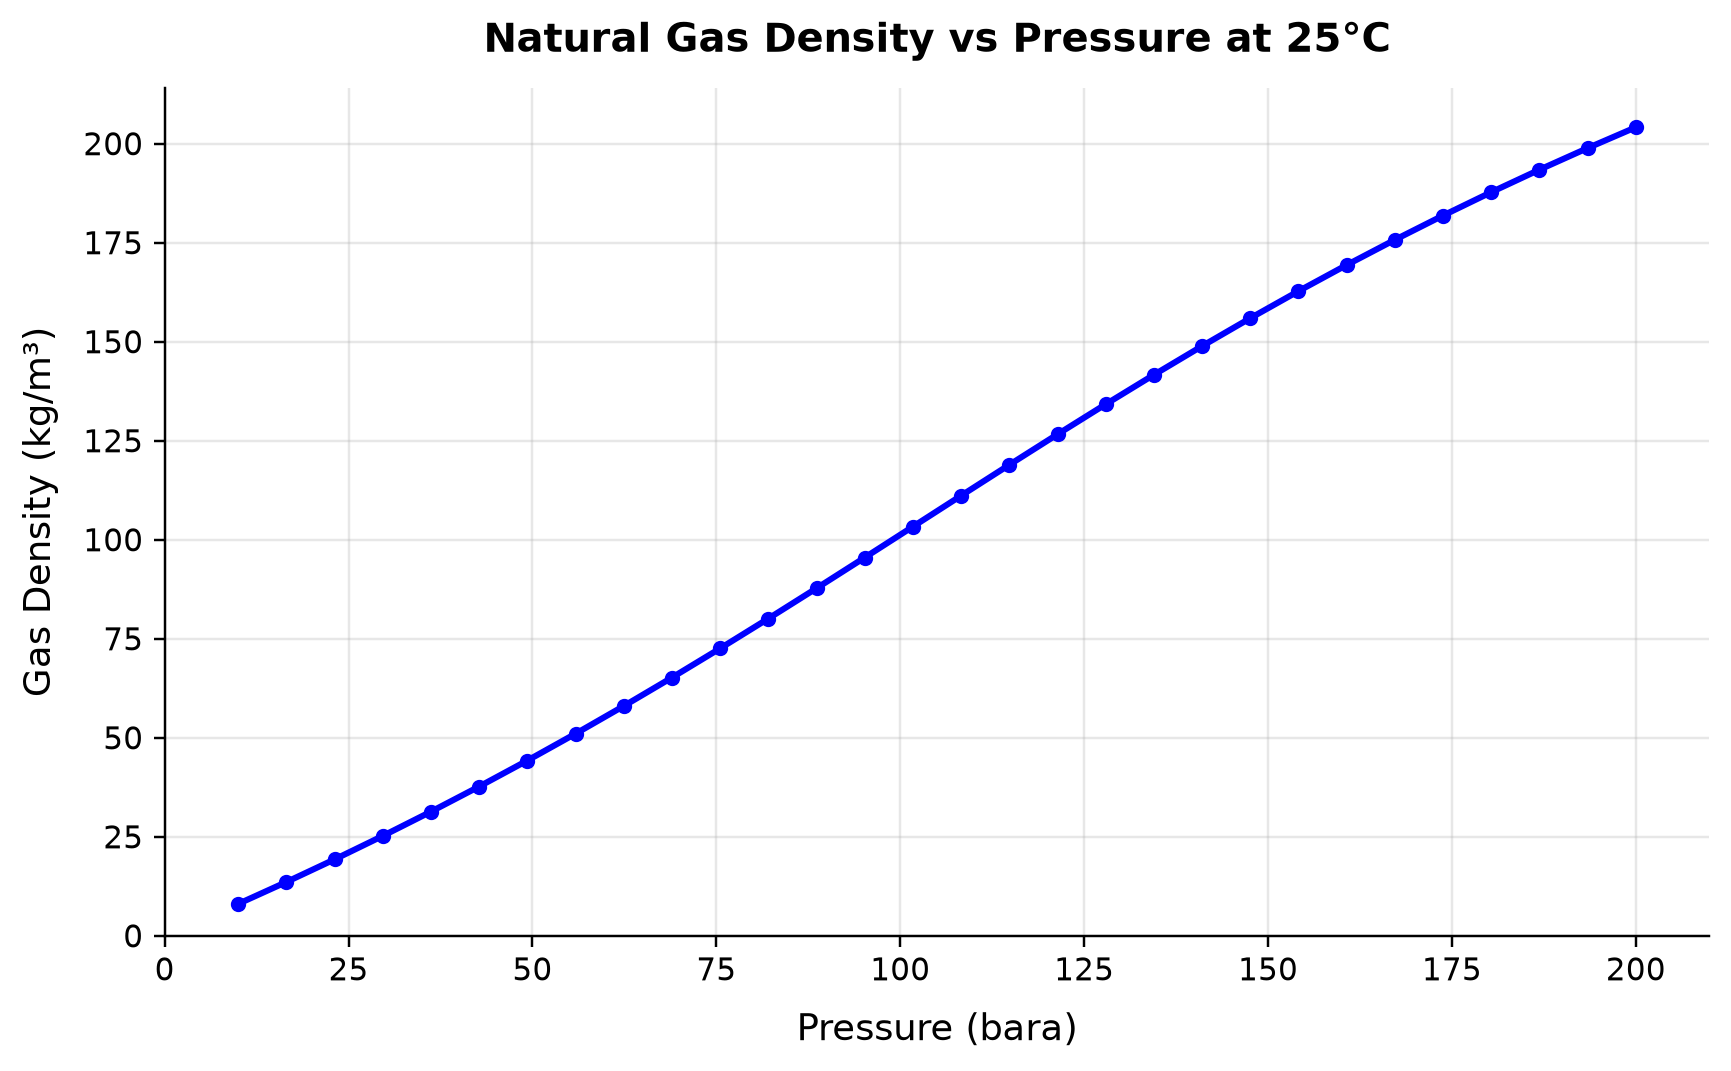

In [4]:
pressures = np.linspace(10, 200, 30)
densities = []
T_C = 25.0
T_K = 273.15 + T_C

for P in pressures:
    fluid = create_natural_gas(T_K, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    densities.append(fluid.getDensity("kg/m3"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures, densities, 'b-o', markersize=4, linewidth=2)
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Gas Density (kg/m³)', fontsize=12)
ax.set_title('Natural Gas Density vs Pressure at 25°C', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 210)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig01_density_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Density range: {min(densities):.1f} – {max(densities):.1f} kg/m³")

**Executed-figure discussion.** Gas Density spans 8.063–204.1 kg/m³ across the plotted cases.

Compression reduces the volume occupied by a fixed gas mass; real-gas interactions make the density change nonlinear. A fixed mass flow can impose a much larger actual-volume load on low-pressure piping and compressor suction equipment. Use actual inlet density at each operating case when converting mass rate to velocity, vessel gas load and compressor inlet volume.


## 1.3 Figure 2 — Compressibility Factor (Z) vs Pressure

The Z-factor quantifies the deviation from ideal gas behavior (Z=1 for ideal gas).
At moderate pressures Z drops below 1 (attractive forces dominate), then rises
at very high pressures (repulsive forces).

Z-factor range: 0.7503 – 0.9744


ch01_introduction_figures.ipynb:cell8:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


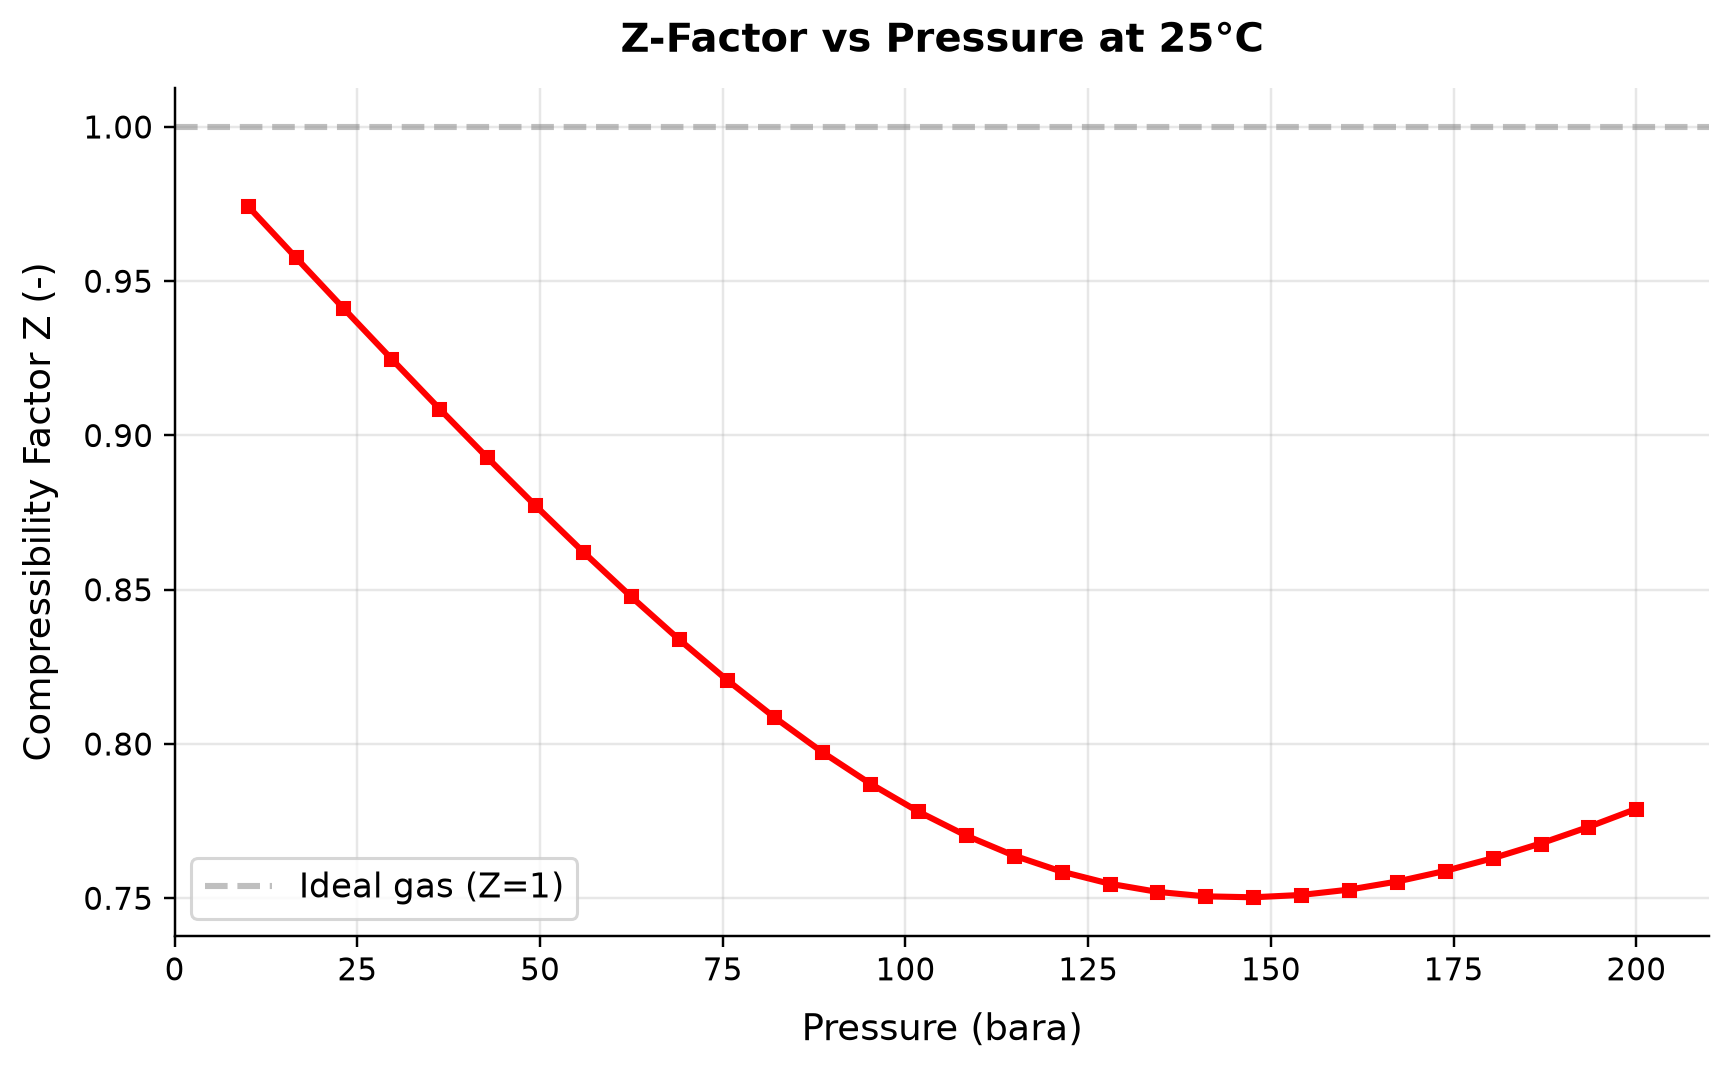

In [5]:
z_factors = []

for P in pressures:
    fluid = create_natural_gas(T_K, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    z_factors.append(fluid.getPhase("gas").getZ())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures, z_factors, 'r-s', markersize=4, linewidth=2)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ideal gas (Z=1)')
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Compressibility Factor Z (-)', fontsize=12)
ax.set_title('Z-Factor vs Pressure at 25°C', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 210)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig02_z_factor_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Z-factor range: {min(z_factors):.4f} – {max(z_factors):.4f}")

**Executed-figure discussion.** Compressibility Factor Z spans 0.7503–0.9744 across the plotted cases.

Attractive interactions initially reduce gas volume below the ideal-gas prediction; repulsive effects become more important as pressure increases. A constant Z can distort standard-to-actual volume conversion and the pressure dependence of available throughput. Evaluate Z at the local temperature, pressure and composition along the system rather than applying a single standard-condition value.


## 1.4 Figure 3 — Phase Envelope

The phase envelope (P-T diagram) shows the bubble-point and dew-point curves
that bound the two-phase region. This is critical for understanding at which
conditions liquid may drop out from the gas.

dewT: 39 physical continuation points; 1 sentinel entries excluded
bubT: 27 physical continuation points; 1 sentinel entries excluded


ch01_introduction_figures.ipynb:cell10:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


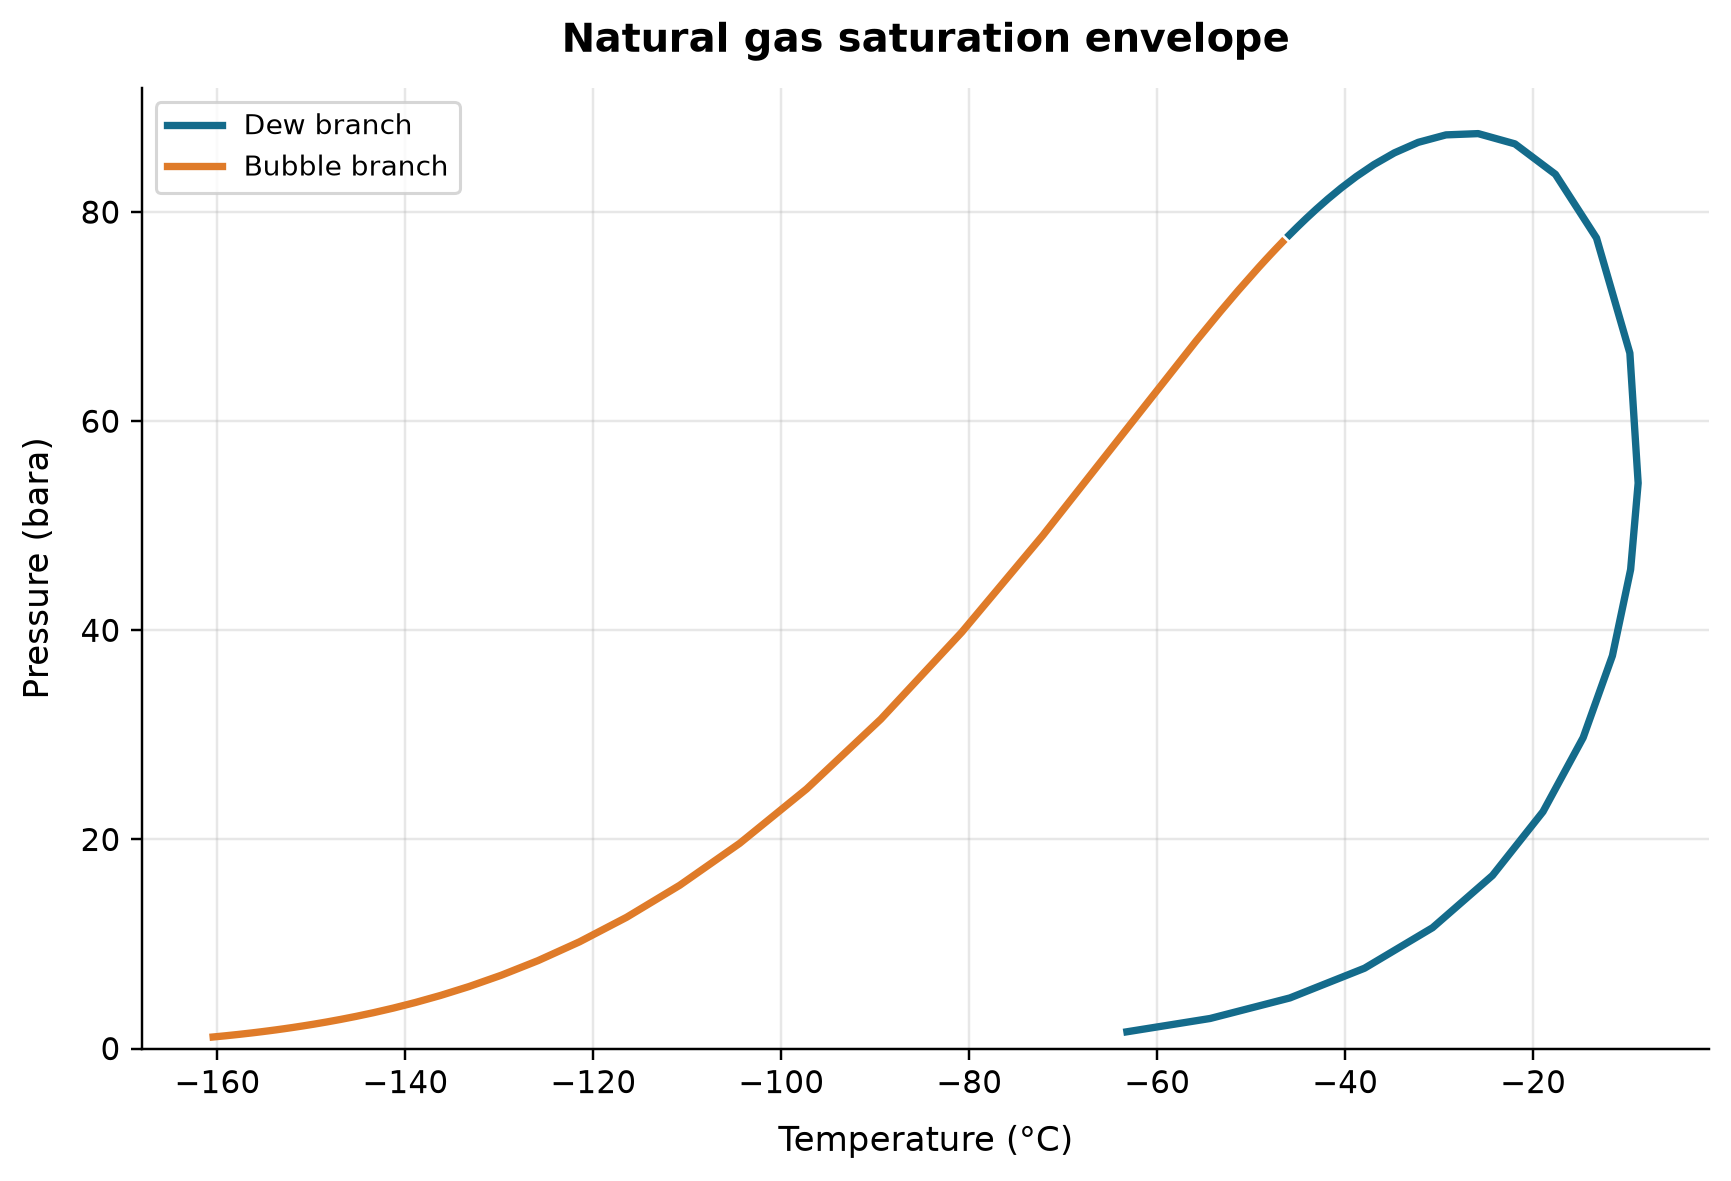

In [6]:
fluid_env = create_natural_gas(273.15 + 25.0, 50.0)
fluid_env.setMultiPhaseCheck(True)
ops_env = ThermodynamicOperations(fluid_env)
ops_env.calcPTphaseEnvelope(True, 1.0)
branches = []
for t_key, p_key in [("dewT", "dewP"), ("bubT", "bubP")]:
    raw_t, raw_p = np.asarray(ops_env.get(t_key), dtype=float), np.asarray(ops_env.get(p_key), dtype=float)
    valid = np.isfinite(raw_t) & np.isfinite(raw_p) & (raw_t > 0) & (raw_p > 0)
    print(f"{t_key}: {valid.sum()} physical continuation points; {(~valid).sum()} sentinel entries excluded")
    if valid.sum() >= 2:
        branches.append((raw_t[valid] - 273.15, raw_p[valid]))
assert branches, "Envelope solver returned no finite physical branch"
# Continuation getter labels can be swapped: the dew branch contains the cricondentherm.
branches.sort(key=lambda branch: np.max(branch[0]), reverse=True)
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, (temperature, pressure) in enumerate(branches):
    label = ("Dew branch" if i == 0 else "Bubble branch") if len(branches) == 2 else "Traced saturation branch"
    ax.plot(temperature, pressure, linewidth=2.4, label=label)
ax.set(xlabel="Temperature (°C)", ylabel="Pressure (bara)", title="Natural gas saturation envelope")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_phase_envelope.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Dew branch: pressure spans 1.603–87.5 bara across the plotted cases. Bubble branch: pressure spans 1.105–77.13 bara across the plotted cases.

The saturation boundary identifies states where a second hydrocarbon phase can first appear; it is a thermodynamic boundary, not an operating trajectory. Expansion and cooling can cross into two-phase flow even when the upstream stream is a single gas phase. Overlay the actual operating path and uncertainty envelope, using only finite traced branches and the contract pressure basis for dew-point limits.


## 1.5 Figure 4 — Production Rate Sensitivity

This conceptual figure illustrates how different operating parameters
(wellhead pressure, separator pressure, pipeline diameter, choke setting)
affect the achievable gas production rate. The relative impacts are estimated
from a simple choke/pipeline flow model.

Pressure (bara) | Actual volume (m3/hr) at 50 t/hr
    30 |    2086.53
    50 |    1199.03
    70 |     822.59
    90 |     617.79
   120 |     446.58


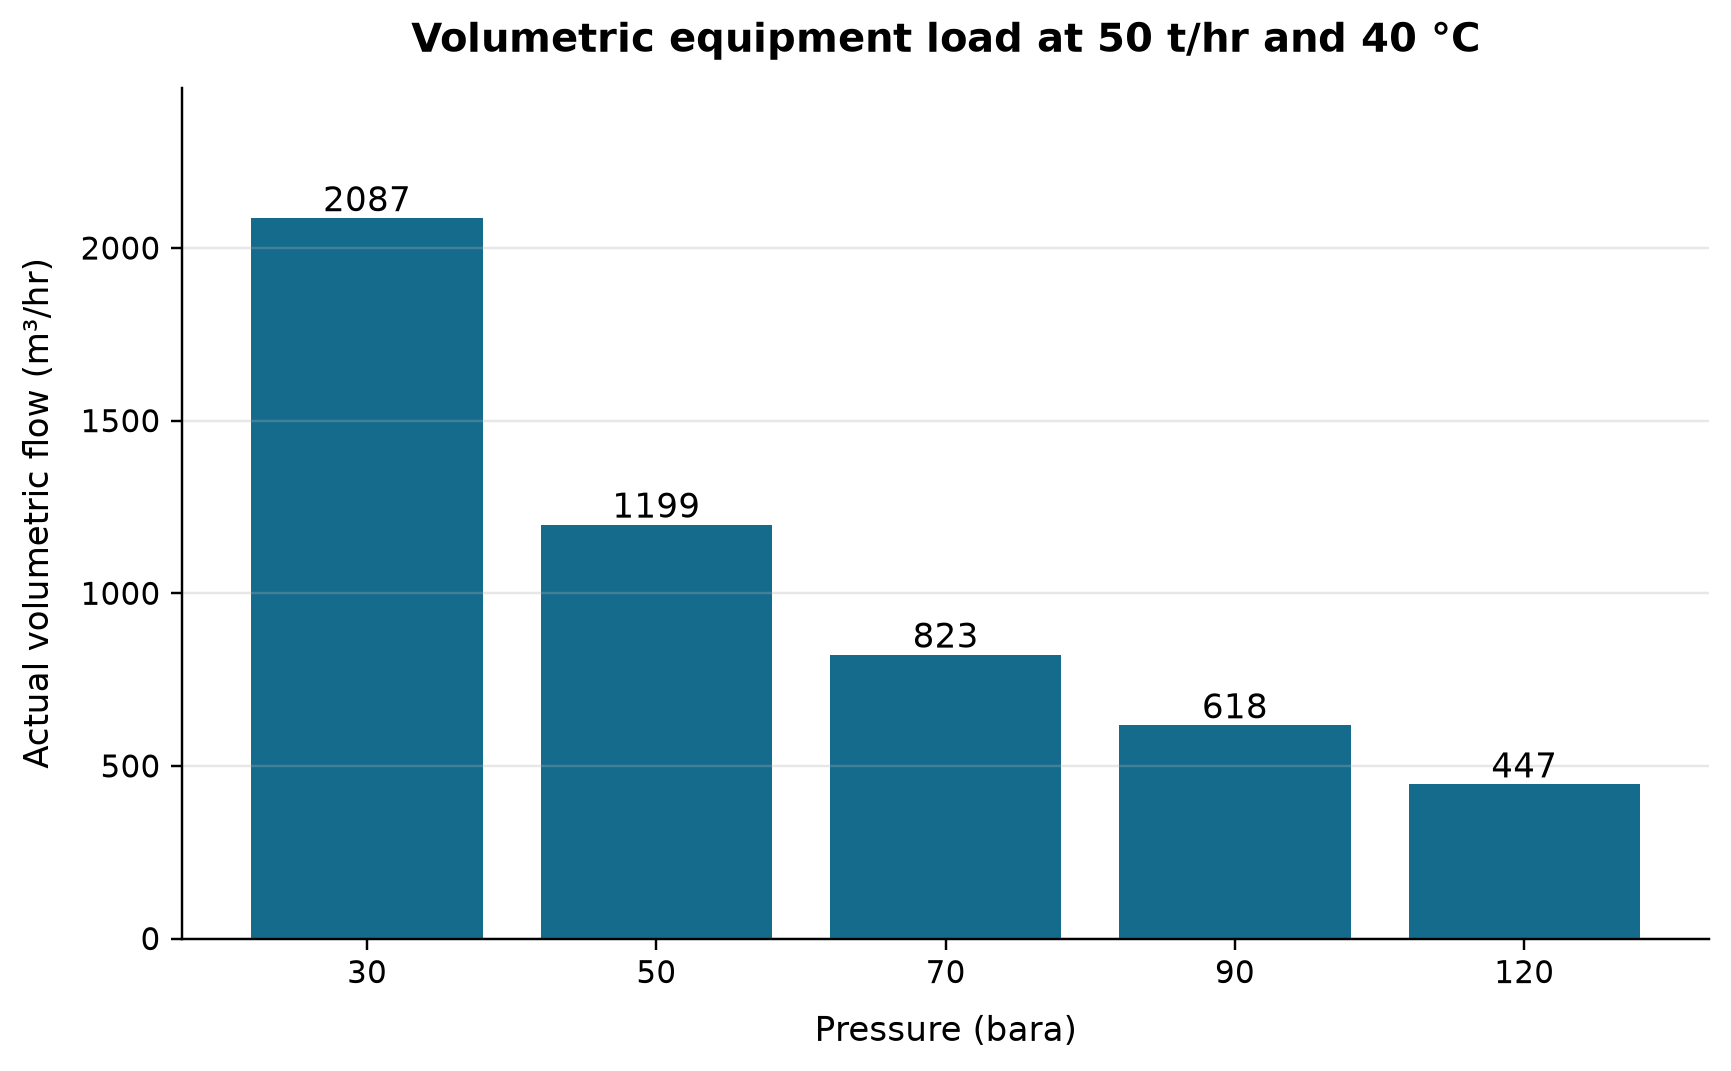

In [7]:
# Actual volumetric load for a specified mass flow; this is not well deliverability.
whp_pressures = [30, 50, 70, 90, 120]
mass_flow_kg_hr = 50000.0
actual_volume_m3_hr = []
for P in whp_pressures:
    fluid = create_natural_gas(273.15 + 40.0, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    actual_volume_m3_hr.append(mass_flow_kg_hr / float(fluid.getDensity("kg/m3")))
assert actual_volume_m3_hr[-1] < actual_volume_m3_hr[0]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(p) for p in whp_pressures], actual_volume_m3_hr, color='#146B8B')
ax.set_xlabel('Pressure (bara)')
ax.set_ylabel('Actual volumetric flow (m³/hr)')
ax.set_title('Volumetric equipment load at 50 t/hr and 40 °C')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(actual_volume_m3_hr)*1.18)
for bar, value in zip(bars, actual_volume_m3_hr):
    ax.text(bar.get_x()+bar.get_width()/2, value+20, f'{value:.0f}', ha='center')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'fig04_production_sensitivity.png', dpi=220, bbox_inches='tight')
plt.show()
print('Pressure (bara) | Actual volume (m3/hr) at 50 t/hr')
for P, value in zip(whp_pressures, actual_volume_m3_hr):
    print(f'{P:6.0f} | {value:10.2f}')


**Executed-figure discussion.** Actual volumetric flow spans 446.6–2087 m³/hr across the plotted cases.

The plotted actual volume is the specified mass flow divided by the NeqSim bulk density at each pressure. Lower-pressure gas imposes a greater actual-volume load for the same mass production; this calculation does not predict well deliverability. Use actual inlet volume for equipment capacity checks, and solve the coupled reservoir and tubing model separately for the production rate.


## Summary

This chapter demonstrated:

1. **Fluid creation** — Building a natural gas model with SRK EOS in NeqSim
2. **Density behavior** — Gas density increases non-linearly with pressure due to real-gas effects
3. **Z-factor** — The compressibility factor drops below 1.0 at moderate pressures, showing deviation from ideal gas
4. **Phase envelope** — The PT diagram shows where two-phase conditions may occur
5. **Production sensitivity** — Wellhead pressure significantly affects deliverability

In the next chapter we will explore the thermodynamic foundations (EOS models and flash calculations) in more detail.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                          Figure  Panel          Series                  Output / unit  Minimum  Maximum  Finite points  Missing points
   fig01_density_vs_pressure.png      1         Curve 1            Gas Density (kg/m³)  8.06343  204.141             30               0
  fig02_z_factor_vs_pressure.png      1         Curve 1   Compressibility Factor Z (-) 0.750315  0.97442             30               0
  fig02_z_factor_vs_pressure.png      1 Ideal gas (Z=1)   Compressibility Factor Z (-)        1        1              2               0
        fig03_phase_envelope.png      1      Dew branch                Pressure (bara)  1.60257  87.5039             27               0
        fig03_phase_envelope.png      1   Bubble branch                Pressure (bara)  1.10517  77.1293             39               0
fig04_production_sensitivity.png      1          Bars 1 Actual volumetric flow (m³/hr)  446.578  2086.53              5               0
